# RT-DETR-1 工业流水线零件缺陷检测教学案例（NEU Surface Defect Dataset）

## 1. 知识点简述：只有类别标签时如何“生成 bounding box”
在工业视觉中，常见数据是**图像级标签**（只知道有哪类缺陷），而目标检测模型（如 RT-DETR）训练需要**目标框标注**。  
本案例采用“传统图像处理 + 规则约束”的方式，为每张图自动生成**伪框（pseudo bounding boxes）**，再把伪框组织成 COCO 检测标注用于训练。

> 这属于一种弱监督/伪标注思路：先用较低成本方法构造可训练数据，再通过模型迭代提升标注和性能。

## 2. 教学意义
- 让学生理解：分类数据如何迁移到检测任务。
- 让学生掌握：从原始数据到可训练检测数据集的完整工程流程。
- 让学生体验：RT-DETR 在工业缺陷场景中的训练、评估与误差分析。

## 3. 环境与目录约定

- 工作目录：`D:/xiangmu/j30-RT-DETR`
- 原始数据目录：`data/NEU-DET/IMAGES`
- 本案例自动生成目录：`data/neu_pseudo_det`

说明：本 notebook 假设原始数据没有框标注，仅通过图像和类别信息（由文件名前缀解析）生成伪框。

In [2]:
import json
import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# 可复现性
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ROOT = Path("D:/xiangmu/j30-RT-DETR")
RAW_IMG_DIR = ROOT / "data/NEU-DET/IMAGES"
OUT_ROOT = ROOT / "data/neu_pseudo_det"
OUT_ANN = OUT_ROOT / "annotations"
OUT_VIS = OUT_ROOT / "visualizations"
OUT_SPLIT = OUT_ROOT / "splits"

for p in [OUT_ROOT, OUT_ANN, OUT_VIS, OUT_SPLIT]:
    p.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("RAW_IMG_DIR exists:", RAW_IMG_DIR.exists())
print("OUT_ROOT:", OUT_ROOT)

ROOT: D:\xiangmu\j30-RT-DETR
RAW_IMG_DIR exists: True
OUT_ROOT: D:\xiangmu\j30-RT-DETR\data\neu_pseudo_det


## 4. 扫描数据并统计类别

这里先从文件名解析类别。NEU 常见命名类似 `crazing_1.jpg`，因此用下划线前缀作为类别名。

图像总数: 1800
类别映射: {'crazing': 1, 'inclusion': 2, 'patches': 3, 'pitted': 4, 'rolled-in': 5, 'scratches': 6}


,class,count
0,crazing,300
1,inclusion,300
2,patches,300
3,pitted,300
4,rolled-in,300
5,scratches,300


D:\Temp\ipykernel_11752\4268408824.py:28: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
D:\Temp\ipykernel_11752\4268408824.py:28: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from current font.
  plt.tight_layout()
D:\Temp\ipykernel_11752\4268408824.py:28: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from current font.
  plt.tight_layout()
D:\Temp\ipykernel_11752\4268408824.py:28: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from current font.
  plt.tight_layout()
D:\Temp\ipykernel_11752\4268408824.py:28: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from current font.
  plt.tight_layout()
D:\Temp\ipykernel_11752\4268408824.py:28: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from current font.
  plt.tight_layout()
d:\anaconda\envs\xm\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED I

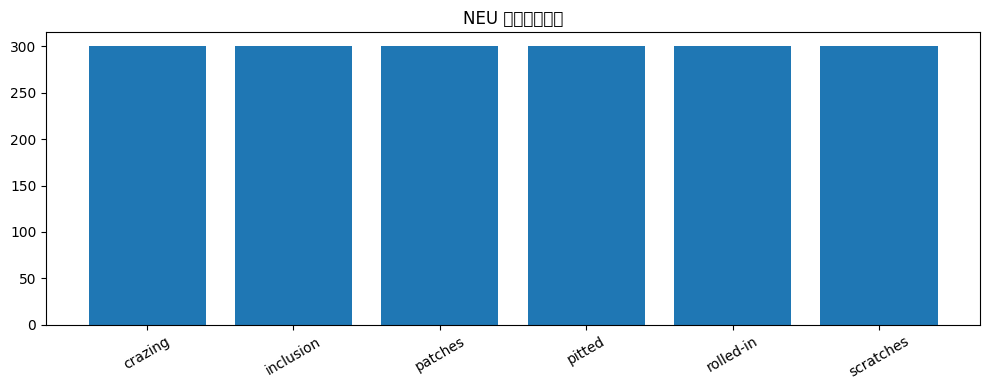

In [3]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

image_paths = sorted([p for p in RAW_IMG_DIR.glob("*") if p.suffix.lower() in IMG_EXTS])
if len(image_paths) == 0:
    raise FileNotFoundError(f"未在 {RAW_IMG_DIR} 找到图像，请检查路径。")

def parse_class_from_name(path: Path) -> str:
    stem = path.stem
    return stem.split("_")[0].lower()

labels = [parse_class_from_name(p) for p in image_paths]
class_counter = Counter(labels)
classes = sorted(class_counter.keys())
class_to_id = {c: i + 1 for i, c in enumerate(classes)}  # COCO 类别从 1 开始
id_to_class = {v: k for k, v in class_to_id.items()}

print(f"图像总数: {len(image_paths)}")
print("类别映射:", class_to_id)

df_stat = pd.DataFrame({"class": list(class_counter.keys()), "count": list(class_counter.values())})
df_stat = df_stat.sort_values("class").reset_index(drop=True)
display(df_stat)

plt.figure(figsize=(10, 4))
plt.bar(df_stat["class"], df_stat["count"])
plt.title("NEU 数据类别分布")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. 伪框生成算法（核心）

思路：
1. 灰度化 + 高斯滤波降噪。  
2. 用拉普拉斯响应增强缺陷区域纹理。  
3. Otsu 自动阈值分割得到候选区域。  
4. 形态学闭运算/开运算去噪并连通。  
5. 取最大连通轮廓外接矩形作为伪框。  

若候选区域异常（过小或过大），使用保底框策略，避免无标注样本。

In [4]:
def xyxy_to_xywh(box):
    x1, y1, x2, y2 = box
    return [float(x1), float(y1), float(x2 - x1), float(y2 - y1)]


def generate_pseudo_bbox(image_bgr, min_area_ratio=0.002, max_area_ratio=0.85, return_mask=False):
    h, w = image_bgr.shape[:2]
    img_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

    lap = cv2.Laplacian(blur, cv2.CV_32F, ksize=3)
    lap = cv2.convertScaleAbs(lap)

    _, mask = cv2.threshold(lap, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    k = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        # 保底框：中心区域
        x1, y1 = int(w * 0.2), int(h * 0.2)
        x2, y2 = int(w * 0.8), int(h * 0.8)
        box = [x1, y1, x2, y2]
        if return_mask:
            return box, mask
        return box

    cnt = max(contours, key=cv2.contourArea)
    x, y, bw, bh = cv2.boundingRect(cnt)
    x1, y1, x2, y2 = x, y, x + bw, y + bh

    area_ratio = (bw * bh) / float(w * h)
    if area_ratio < min_area_ratio or area_ratio > max_area_ratio:
        # 面积比例异常时，用稳健保底框
        x1, y1 = int(w * 0.15), int(h * 0.15)
        x2, y2 = int(w * 0.85), int(h * 0.85)

    box = [int(x1), int(y1), int(x2), int(y2)]
    if return_mask:
        return box, mask
    return box

## 6. 批量生成伪框并导出 COCO 标注

这里会生成：
- `all_pseudo_coco.json`：全量伪框检测标注
- `pseudo_boxes_preview.csv`：便于教学查看的框信息表

生成伪框: 100%|██████████| 1800/1800 [00:03<00:00, 599.41it/s]

COCO 标注已保存: D:\xiangmu\j30-RT-DETR\data\neu_pseudo_det\annotations\all_pseudo_coco.json
CSV 预览已保存: D:\xiangmu\j30-RT-DETR\data\neu_pseudo_det\annotations\pseudo_boxes_preview.csv
images: 1800 annotations: 1800


,file_name,class,x1,y1,x2,y2,w,h,area_ratio
0,crazing_1.jpg,crazing,30,30,170,170,140,140,0.49
1,crazing_10.jpg,crazing,30,30,170,170,140,140,0.49
2,crazing_100.jpg,crazing,30,30,170,170,140,140,0.49
3,crazing_101.jpg,crazing,30,30,170,170,140,140,0.49
4,crazing_102.jpg,crazing,30,30,170,170,140,140,0.49


d:\anaconda\envs\xm\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20266 (\N{CJK UNIFIED IDEOGRAPH-4F2A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\xm\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26694 (\N{CJK UNIFIED IDEOGRAPH-6846}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\xm\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\xm\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31215 (\N{CJK UNIFIED IDEOGRAPH-79EF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\envs\xm\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21344 (\N{CJK UNIFIED IDEOGRAPH-5360}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\anaconda\env

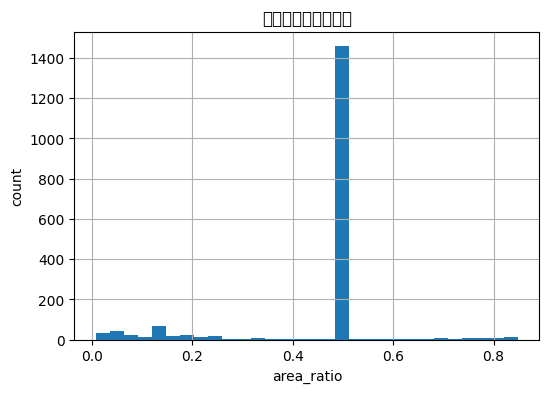

In [5]:
images_coco = []
annotations_coco = []
preview_rows = []
ann_id = 1

for img_id, img_path in enumerate(tqdm(image_paths, desc="生成伪框"), start=1):
    img = cv2.imread(str(img_path))
    if img is None:
        continue

    h, w = img.shape[:2]
    cls_name = parse_class_from_name(img_path)
    cls_id = class_to_id[cls_name]

    box = generate_pseudo_bbox(img)
    x1, y1, x2, y2 = box
    bw, bh = x2 - x1, y2 - y1

    images_coco.append({
        "id": img_id,
        "file_name": img_path.name,
        "width": w,
        "height": h
    })

    annotations_coco.append({
        "id": ann_id,
        "image_id": img_id,
        "category_id": cls_id,
        "bbox": xyxy_to_xywh(box),
        "area": float(bw * bh),
        "iscrowd": 0
    })

    preview_rows.append({
        "file_name": img_path.name,
        "class": cls_name,
        "x1": x1,
        "y1": y1,
        "x2": x2,
        "y2": y2,
        "w": bw,
        "h": bh,
        "area_ratio": (bw * bh) / float(w * h)
    })
    ann_id += 1

categories_coco = [{"id": cid, "name": cname} for cname, cid in class_to_id.items()]
all_coco = {
    "info": {"description": "NEU pseudo-bbox detection dataset for RT-DETR teaching"},
    "licenses": [],
    "images": images_coco,
    "annotations": annotations_coco,
    "categories": categories_coco
}

all_coco_path = OUT_ANN / "all_pseudo_coco.json"
with open(all_coco_path, "w", encoding="utf-8") as f:
    json.dump(all_coco, f, ensure_ascii=False, indent=2)

df_preview = pd.DataFrame(preview_rows)
csv_path = OUT_ANN / "pseudo_boxes_preview.csv"
df_preview.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("COCO 标注已保存:", all_coco_path)
print("CSV 预览已保存:", csv_path)
print("images:", len(images_coco), "annotations:", len(annotations_coco))
display(df_preview.head())

df_preview["area_ratio"].hist(bins=30, figsize=(6, 4))
plt.title("伪框面积占比直方图")
plt.xlabel("area_ratio")
plt.ylabel("count")
plt.show()

## 7. 可视化中间结果：伪框与分割掩码抽样检查

教学建议：先看自动框质量，再决定是否进入模型训练。

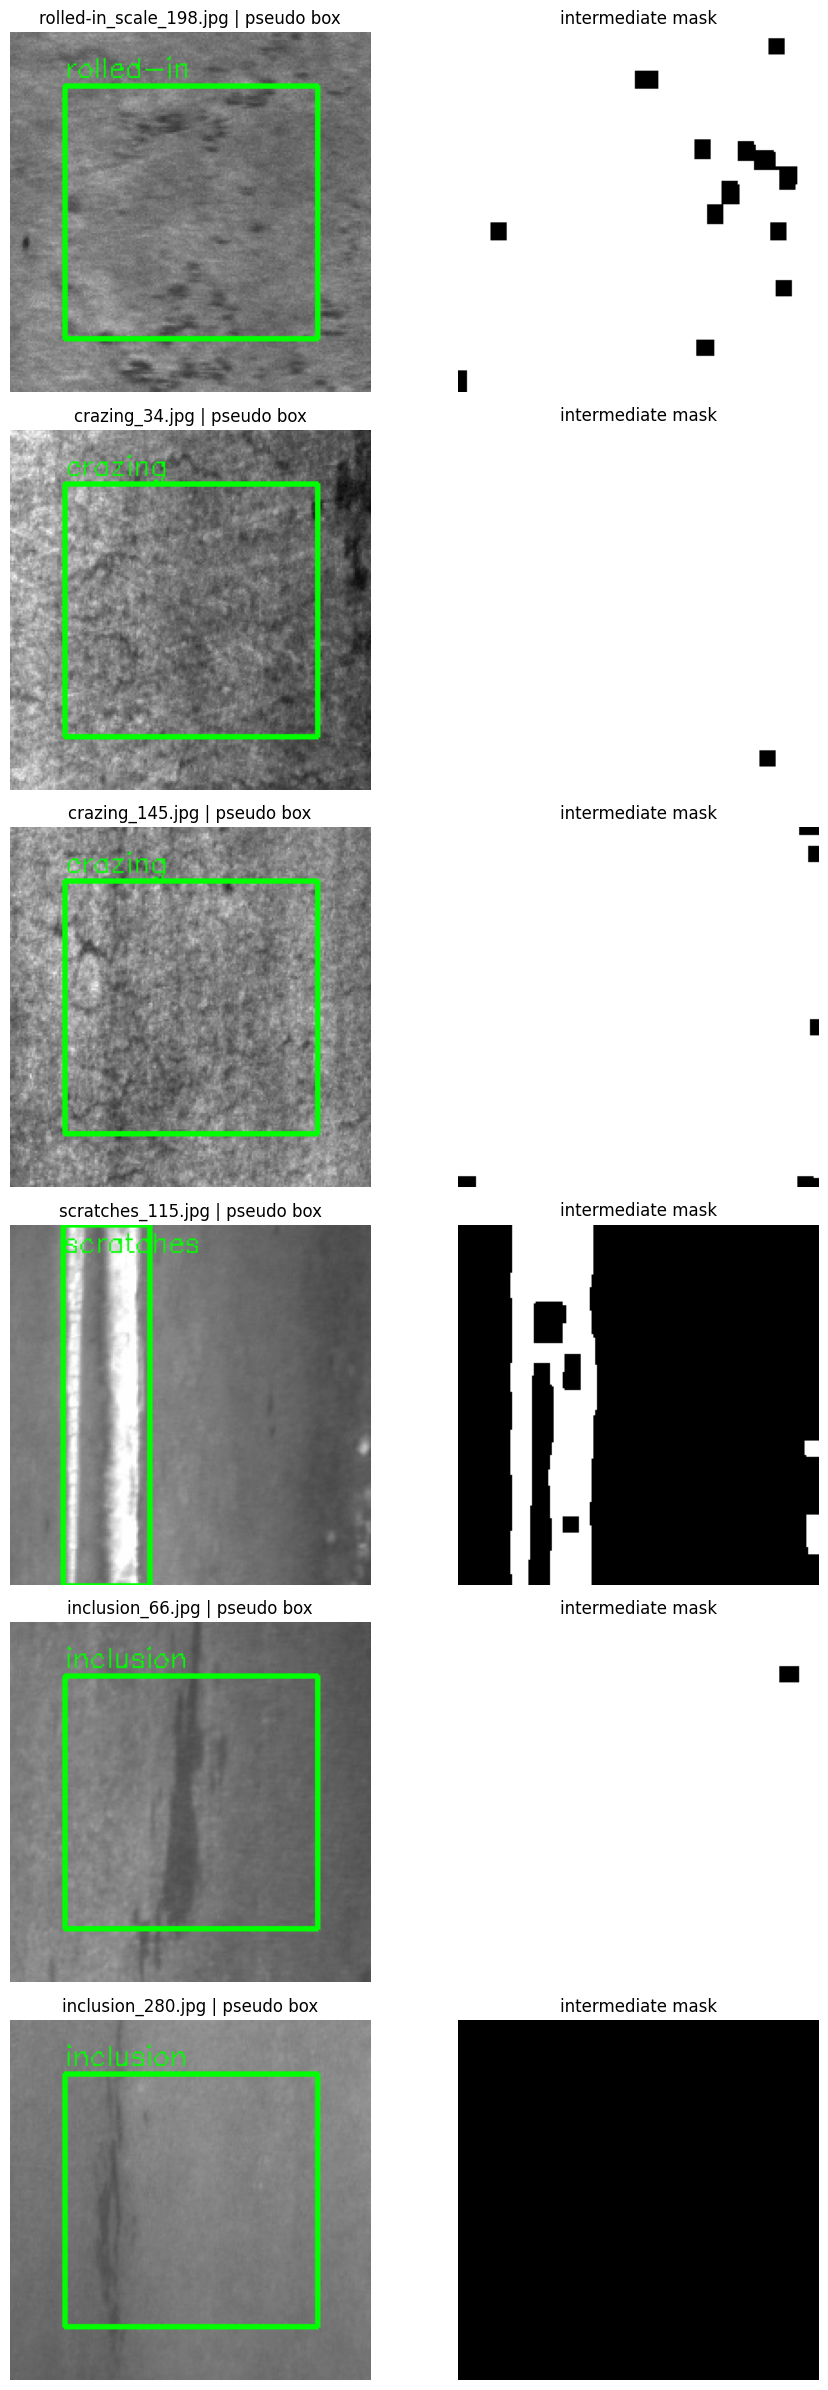

In [6]:
sample_paths = random.sample(image_paths, k=min(6, len(image_paths)))

fig, axes = plt.subplots(len(sample_paths), 2, figsize=(10, 4 * len(sample_paths)))
if len(sample_paths) == 1:
    axes = np.array([axes])

for i, p in enumerate(sample_paths):
    img = cv2.imread(str(p))
    box, mask = generate_pseudo_bbox(img, return_mask=True)
    x1, y1, x2, y2 = box

    vis = img.copy()
    cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(vis, parse_class_from_name(p), (x1, max(15, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

    axes[i, 0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"{p.name} | pseudo box")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title("intermediate mask")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## 8. 划分训练/验证/测试集并导出 COCO 子集

采用分层划分（按类别分布），默认比例：训练 70%，验证 20%，测试 10%。

In [7]:
# 为每张图建立索引
img_name_to_id = {img["file_name"]: img["id"] for img in images_coco}
img_id_to_record = {img["id"]: img for img in images_coco}
img_id_to_ann = {ann["image_id"]: ann for ann in annotations_coco}  # 本案例每图一个框

all_names = [p.name for p in image_paths]
all_labels = [parse_class_from_name(p) for p in image_paths]

train_names, temp_names, train_labels, temp_labels = train_test_split(
    all_names, all_labels, test_size=0.3, random_state=SEED, stratify=all_labels
)
val_names, test_names, val_labels, test_labels = train_test_split(
    temp_names, temp_labels, test_size=1/3, random_state=SEED, stratify=temp_labels
)

split_map = {
    "train": set(train_names),
    "val": set(val_names),
    "test": set(test_names),
}


def build_coco_subset(name_set):
    subset_images, subset_anns = [], []
    for name in name_set:
        img_id = img_name_to_id[name]
        subset_images.append(img_id_to_record[img_id])
        subset_anns.append(img_id_to_ann[img_id])
    return {
        "info": all_coco["info"],
        "licenses": [],
        "images": subset_images,
        "annotations": subset_anns,
        "categories": categories_coco,
    }

for split_name, name_set in split_map.items():
    split_coco = build_coco_subset(name_set)
    out_json = OUT_ANN / f"{split_name}.json"
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(split_coco, f, ensure_ascii=False, indent=2)

    with open(OUT_SPLIT / f"{split_name}.txt", "w", encoding="utf-8") as f:
        for n in sorted(name_set):
            f.write(n + "\n")

    print(f"{split_name}: images={len(split_coco['images'])}, anns={len(split_coco['annotations'])}")

train: images=1260, anns=1260
val: images=360, anns=360
test: images=180, anns=180


## 8.5 生成 YOLO 格式标签（解决“未检测到标签”）

Ultralytics 默认读取 YOLO 标签（`labels/` 目录）。
为避免训练提示“no labels found”，这里把伪框转换为 YOLO 格式并复制图像到 `images/` 目录。

In [8]:
import shutil

yolo_root = OUT_ROOT / "yolo"
img_out = yolo_root / "images"
lab_out = yolo_root / "labels"

for split_name in ["train", "val", "test"]:
    (img_out / split_name).mkdir(parents=True, exist_ok=True)
    (lab_out / split_name).mkdir(parents=True, exist_ok=True)

# 将 COCO 伪框转换为 YOLO 标签
missing = 0
for split_name, name_set in split_map.items():
    for name in name_set:
        img_src = RAW_IMG_DIR / name
        img_dst = img_out / split_name / name
        if not img_dst.exists():
            shutil.copy2(img_src, img_dst)

        img_id = img_name_to_id[name]
        ann = img_id_to_ann[img_id]
        img_rec = img_id_to_record[img_id]
        w, h = img_rec["width"], img_rec["height"]

        x, y, bw, bh = ann["bbox"]
        xc = (x + bw / 2.0) / w
        yc = (y + bh / 2.0) / h
        bw_n = bw / w
        bh_n = bh / h

        cls_id = ann["category_id"] - 1  # YOLO 从 0 开始
        label_line = f"{cls_id} {xc:.6f} {yc:.6f} {bw_n:.6f} {bh_n:.6f}\n"

        label_path = lab_out / split_name / f"{Path(name).stem}.txt"
        with open(label_path, "w", encoding="utf-8") as f:
            f.write(label_line)

print("YOLO 数据集已生成:", yolo_root)
print("train/val/test 图像数:", {k: len(v) for k, v in split_map.items()})

YOLO 数据集已生成: D:\xiangmu\j30-RT-DETR\data\neu_pseudo_det\yolo
train/val/test 图像数: {'train': 1260, 'val': 360, 'test': 180}


## 9. 生成 RT-DETR 数据配置文件（Ultralytics 格式）

我们使用 Ultralytics 的 RT-DETR 接口训练。这里写入 `neu_rtdetr.yaml`。

In [9]:
import yaml

yaml_dict = {
    "path": str((OUT_ROOT / "yolo").as_posix()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {i: name for i, name in enumerate(classes)}
}

yaml_path = ROOT / "neu_rtdetr.yaml"
with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(yaml_dict, f, allow_unicode=True, sort_keys=False)

print("数据配置文件已生成:", yaml_path)
print(yaml.safe_dump(yaml_dict, allow_unicode=True, sort_keys=False))

数据配置文件已生成: D:\xiangmu\j30-RT-DETR\neu_rtdetr.yaml
path: D:/xiangmu/j30-RT-DETR/data/neu_pseudo_det/yolo
train: images/train
val: images/val
test: images/test
names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted
  4: rolled-in
  5: scratches



## 10. 训练 RT-DETR-1（教学参数）

- 首次运行建议先小 epoch（如 10）验证流程，再增大。  
- 如果没有 GPU，可把 `device='cpu'`，但速度会较慢。

In [ ]:
%%script false  # 已有训练结果可加上，这一行会让整个Cell直接跳过，不执行任何代码
# 若缺包请先执行：pip install -r requirements.txt
from ultralytics import RTDETR
import torch
from pathlib import Path

device = 0 if torch.cuda.is_available() else "cpu"
print("Training device:", device)

# 使用本地权重文件，避免自动下载
local_weight = Path("D:/xiangmu/j30-RT-DETR/rtdetr-l.pt")
if not local_weight.exists():
    raise FileNotFoundError(f"未找到本地权重文件: {local_weight}")

model = RTDETR(str(local_weight))

train_results = model.train(
    data=str(yaml_path),
    epochs=10,
    imgsz=640,
    batch=8,
    workers=0,
    device=device,
    project=str(ROOT / "runs"),
    name="neu_rtdetr_teaching",
    pretrained=True,
    verbose=True
)

print("训练完成，结果目录:", train_results.save_dir)

Training device: 0
Ultralytics 8.4.14  Python-3.10.19 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\xiangmu\j30-RT-DETR\neu_rtdetr.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=D:\xiangmu\j30-RT-DETR\rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=neu_rtdetr_teaching2, nbs=64, nms=False, op

d:\anaconda\envs\xm\lib\site-packages\torch\autograd\graph.py:824: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:97.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/10      6.64G     0.4355      12.14     0.6927          4        640: 100% ━━━━━━━━━━━━ 158/158 2.7s/it 6:602.0ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 2.3it/s 9.9s0.4s
                   all        360        360       0.45      0.306      0.158     0.0474

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


d:\anaconda\envs\xm\lib\site-packages\torch\autograd\graph.py:824: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:97.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/10      7.08G     0.3461      0.817     0.6238          4        640: 100% ━━━━━━━━━━━━ 158/158 4.2s/it 11:101.9ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 2.4it/s 9.4s0.4s
                   all        360        360      0.777      0.848      0.829      0.332

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

       8/10      7.08G     0.2307     0.4005     0.4236          4        640: 100% ━━━━━━━━━━━━ 158/158 4.4s/it 11:332.0ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 2.5it/s 9.3s0.4s
                   all        360        360      0.933      0.906      0.918      0.594

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


d:\anaconda\envs\xm\lib\site-packages\torch\autograd\graph.py:824: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:97.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       9/10      7.08G     0.2452     0.3929     0.4379          4        640: 100% ━━━━━━━━━━━━ 158/158 3.0s/it 7:582.2ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 2.4it/s 9.5s0.4s
                   all        360        360      0.934      0.925      0.929      0.569

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


d:\anaconda\envs\xm\lib\site-packages\torch\autograd\graph.py:824: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:97.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      10/10      7.08G     0.2367     0.3456     0.4315          4        640: 100% ━━━━━━━━━━━━ 158/158 4.4s/it 11:331.9ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 2.4it/s 9.8s0.4s
                   all        360        360      0.945      0.935      0.946      0.515

10 epochs completed in 1.618 hours.
Optimizer stripped from D:\xiangmu\j30-RT-DETR\runs\neu_rtdetr_teaching2\weights\last.pt, 66.2MB
Optimizer stripped from D:\xiangmu\j30-RT-DETR\runs\neu_rtdetr_teaching2\weights\best.pt, 66.2MB

Validating D:\xiangmu\j30-RT-DETR\runs\neu_rtdetr_teaching2\weights\best.pt...
Ultralytics 8.4.14  Python-3.10.19 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
rt-detr-l summary: 310 layers, 31,996,070 parameters, 0 gradients, 103.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 2.5it/s 9.4s0.4s
                   all      

## 11. 评估与推理可视化

这里输出验证集指标，并在测试图像上可视化预测框。

Ultralytics 8.4.14  Python-3.10.19 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
rt-detr-l summary: 310 layers, 31,996,070 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 119.230.8 MB/s, size: 13.5 KB)
val: Scanning D:\xiangmu\j30-RT-DETR\data\neu_pseudo_det\yolo\labels\val.cache... 360 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 360/360  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 1.6it/s 14.4s0.6s
                   all        360        360      0.935      0.903      0.919      0.594
               crazing         60         60      0.993          1      0.995      0.797
             inclusion         60         60      0.922       0.95      0.941      0.499
               patches         60         60      0.977      0.983      0.981      0.624
                pitted         60         60      0.997          1      0.995      0.525
      

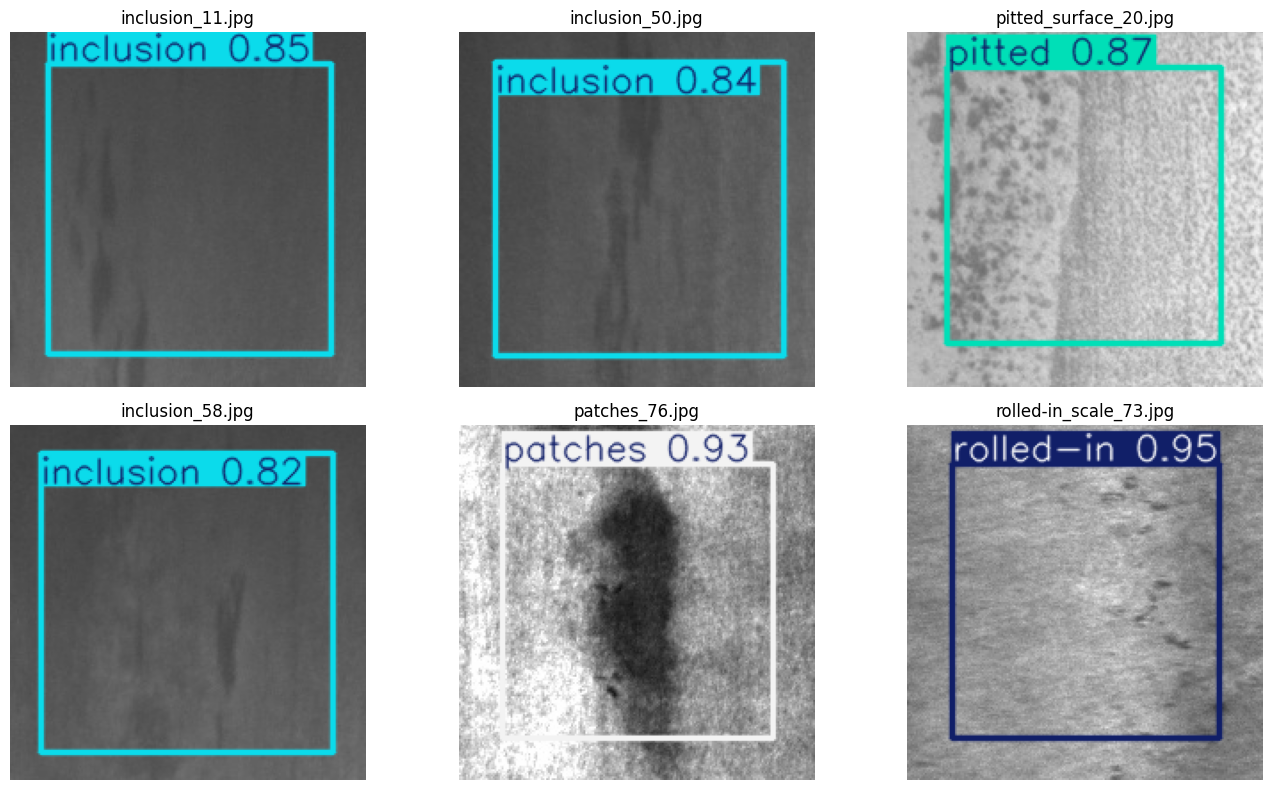

In [11]:
# 验证
metrics = model.val(data=str(yaml_path), split="val", device=device)
print(metrics)

# 推理可视化（随机抽 6 张测试图片）
test_image_paths = [RAW_IMG_DIR / n for n in sorted(list(split_map["test"]))]
show_paths = random.sample(test_image_paths, k=min(6, len(test_image_paths)))

pred_results = model.predict(
    source=[str(p) for p in show_paths],
    conf=0.25,
    iou=0.6,
    device=device,
    verbose=False
)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, r in enumerate(pred_results):
    plotted = r.plot()  # BGR
    axes[i].imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    axes[i].set_title(Path(r.path).name)
    axes[i].axis("off")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

## 12. 拓展与思考（含解答思路）

### 问题 1：伪框质量不高怎么办？
**思路**：
- 做“人工小样本精标”作为验证集，量化伪框与真框 IoU。
- 替换伪框策略：尝试 Canny + 连通域、多阈值融合、显著性检测。
- 用第一轮训练模型做二次伪标注（self-training），迭代提升质量。

### 问题 2：为什么工业缺陷检测常常难迁移？
**思路**：
- 缺陷尺度小、对比弱、纹理复杂，且不同产线光照差异大。
- 需要做域适配：风格增强、颜色扰动、直方图匹配、跨域微调。

### 问题 3：如何评价这个教学方案是否有效？
**思路**：
- 过程指标：伪框可视化抽检通过率、各类别样本平衡度。
- 结果指标：mAP50、mAP50-95、漏检率（FN）与误检率（FP）。
- 教学指标：学生是否能独立完成“从分类到检测”的工程闭环。

### 可布置的作业
1. 把伪框算法改成两种以上策略并对比 mAP。  
2. 在同样伪框数据上，比较 YOLOv8 与 RT-DETR 的速度/精度。  
3. 增加误检样本分析报告，给出至少 3 条可实施改进方案。